In [ ]:
import re
import pandas as pd
import numpy as np

from pathlib import Path

from pythainlp.tokenize import word_detokenize
from tqdm import tqdm_notebook

import seaborn as sns


In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "./thsarabunnew-webfont.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'TH Sarabun New'

In [7]:
path_folder = Path("data/")

In [8]:
import chardet

rawdata = open(path_folder / "train.txt", 'rb').read()
result = chardet.detect(rawdata)

print(result)

{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}


In [10]:
texts = []
labels = []

with open(path_folder / "train.txt", encoding="utf-8") as f:
    for line in f:
        texts.append(line.strip())

with open(path_folder / "train_label.txt", encoding="utf-8") as f:
    for line in f:
        labels.append(line.strip())

df = pd.DataFrame({ "category": labels, "texts": texts })
del texts
del labels

df.to_csv("_train.csv", index=False)

df.shape

(24063, 2)

In [12]:
texts = []
labels = []

with open(path_folder / "test.txt",encoding="utf-8") as f:
    for line in f:
        texts.append(line.strip())

test_df = pd.DataFrame({ "category": "neu", "texts": texts })
del texts
del labels

test_df.to_csv("_test.csv", index=False)
test_df.shape

(2674, 2)

In [13]:
df.describe()

,category,texts
count,24063,24063
unique,4,24014
top,neu,#ERROR!
freq,13105,31


In [14]:
df.head()

,category,texts
0,neu,ประเทศเราผลิตและส่งออกยาสูบเยอะสุดในโลกจิงป่าวคับ
1,neu,คะ
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค
3,neu,😅😅😅
4,neu,สวัสดีวันพุธ แนน อะไรนะ


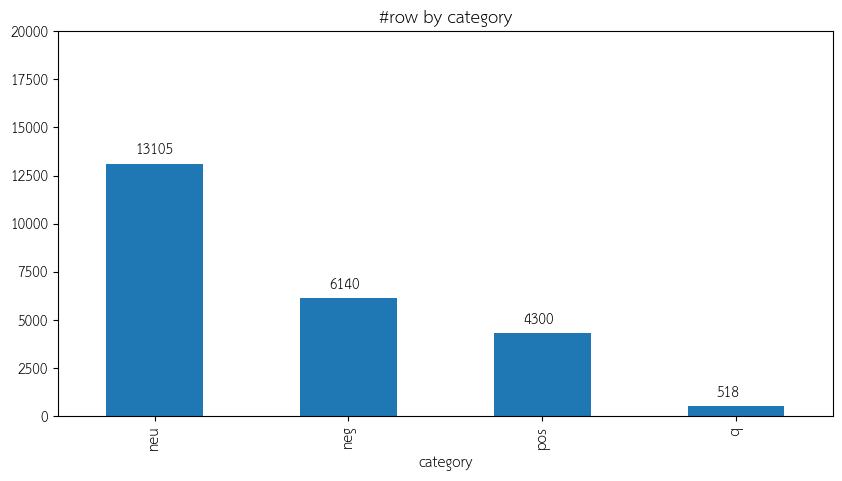

In [16]:
row_count_by_category = df.category.value_counts()
ax = row_count_by_category.plot(kind="bar", title="#row by category", figsize=(10, 5))
ax.set_ylim(0, 20000)
for i, label in enumerate(row_count_by_category):
    ax.annotate(str(label), (i-0.1, label + 500))

In [17]:
df["length"] = df["texts"].apply(word_detokenize).apply(len)
df.head()

,category,texts,length
0,neu,ประเทศเราผลิตและส่งออกยาสูบเยอะสุดในโลกจิงป่าวคับ,49
1,neu,คะ,2
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค,27
3,neu,😅😅😅,5
4,neu,สวัสดีวันพุธ แนน อะไรนะ,23


<Axes: >

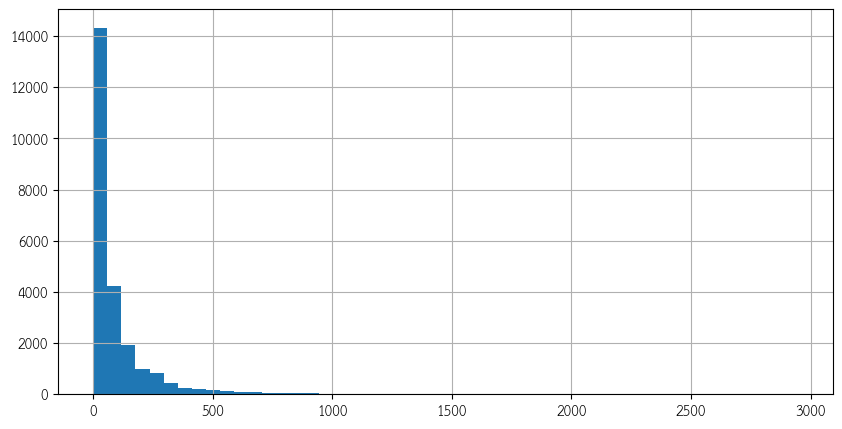

In [18]:
df["length"].hist(bins=50, figsize=(10, 5))

In [20]:
df["length"].describe()

count    24063.000000
mean       103.097162
std        179.406963
min          1.000000
25%         20.000000
50%         42.000000
75%        108.000000
max       2946.000000
Name: length, dtype: float64

In [25]:
df[df["length"] >= 740]

,category,texts,length
47,neg,ขออนุญาติ ติบริการของพนักงานทางร้านด้วยค่ะ #mk...,864
52,neu,DJ.ชมพู แจกฟรี! บัตร Chang music แจกอีกครั้งนะ...,818
124,neu,(‘GET 102.5’ ร่วมสร้างปรากฏการณ์เรืองแสงสุดยิ่...,918
141,neu,รพ.กรุงเทพพัทยา จัด Workshop : ไขความลับสุขภาพ...,1075
183,neu,จันทร์ Shock โลก The Return คืนนี้ ดีเจโอ๊ต ปร...,1349
...,...,...,...
23864,neu,"รอบ 8 คน ระทึก ""พุฒ อุบล"" ท้าชน ""จิ๋ว เชียงราย...",823
23983,neu,#เมนูเพื่อสุขภาพจากนักโภชนาการ ฟรุ๊ตสลัดเชื่อม...,955
23991,neu,ใช่ครับผม แต่จะมีบางสาขาเท่านั้นนะคร้าบตอนนี้ต...,826
24020,neu,เกร็ดความรู้ วิธีรักษาสิวแบบธรรมชาติด้วยใบสะเด...,1932


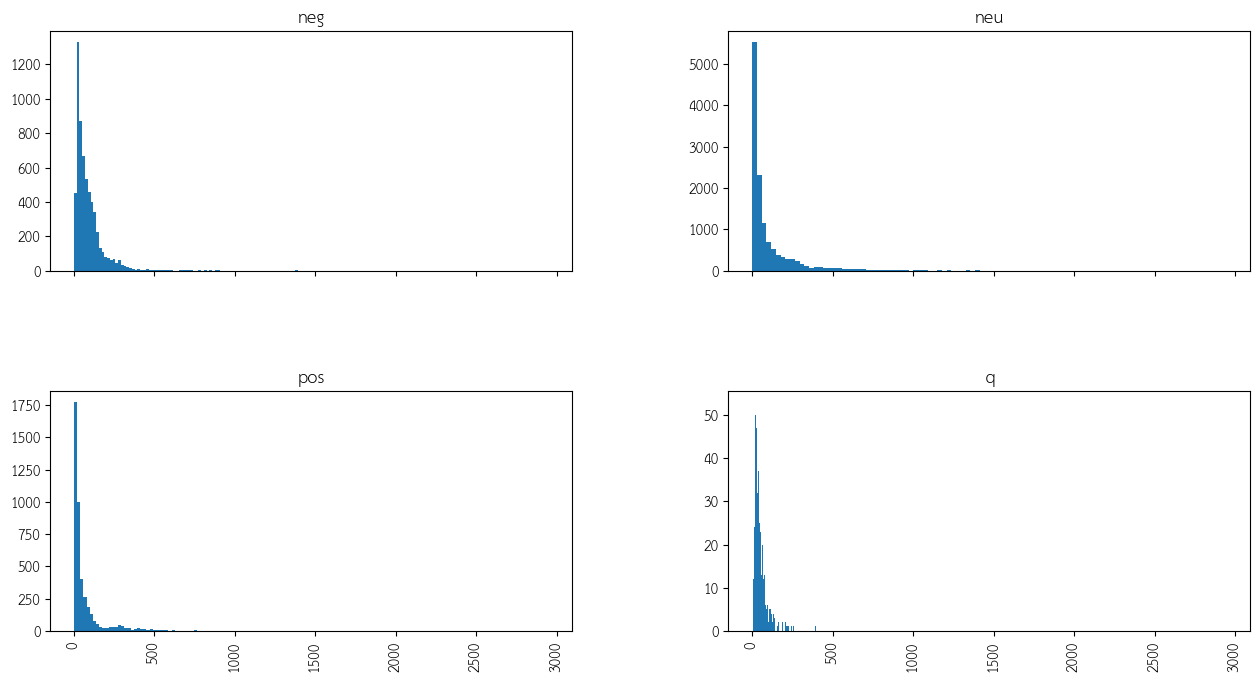

In [24]:
df.hist(column="length", by="category" , bins=100, figsize=(15, 8), sharex=True)
plt.show()

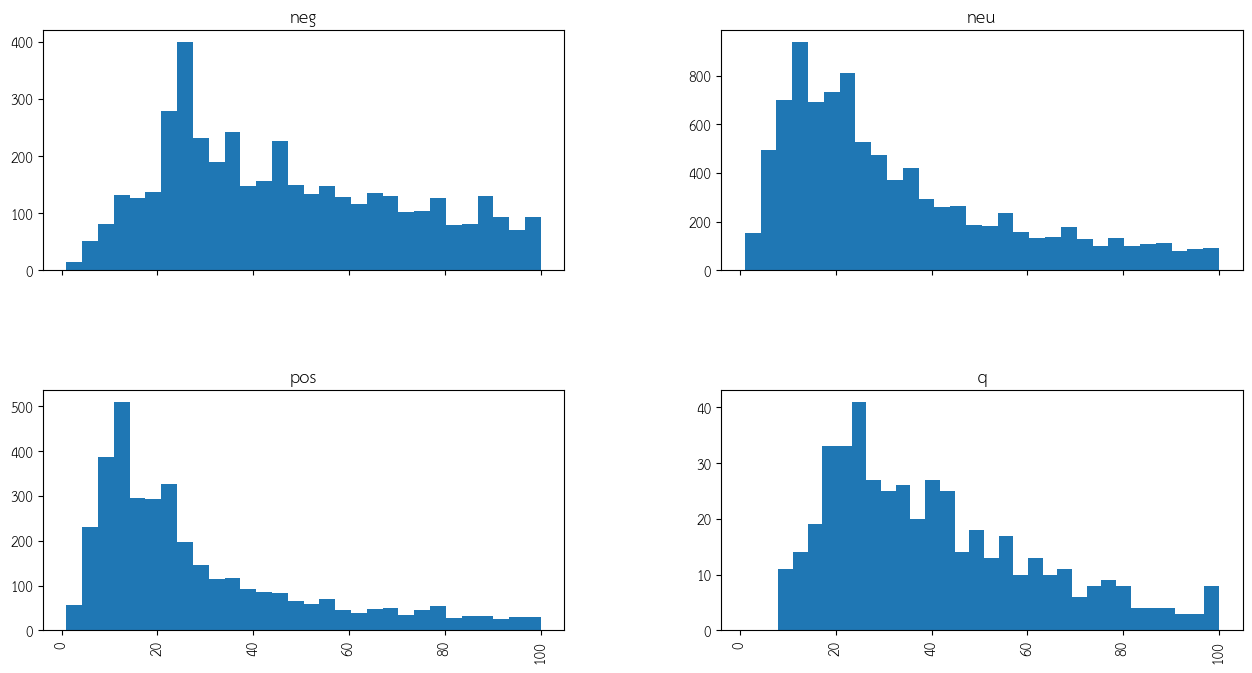

In [26]:
df[df["length"] <= 100].hist(column="length", by="category", bins=30, figsize=(15,8), sharex=True)
plt.show()

In [ ]:
def top_feats(Xtr, features, grp_ids=None, mid_tfidf=0.1, top_n=25):

    return